<a href="https://colab.research.google.com/github/Yeabebe/earthquake-detection-ai/blob/main/earthquake_lstm_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install & Import Libraries

In [1]:
!pip install numpy pandas scikit-learn tensorflow matplotlib joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import joblib

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


Upload Dataset

In [2]:
from google.colab import files

uploaded = files.upload()

Saving IEB_export.csv to IEB_export.csv


Load Dataset

In [3]:
df = pd.read_csv("IEB_export.csv")

print("\nDataset Loaded Successfully")
print(df.head())

print("\nDataset Shape:")
print(df.shape)


Dataset Loaded Successfully
   Year  Month  Day      Time     Lat      Lon  Depth  Mag  \
0  2026      5   10  22:01:16  9.3613  40.0258   10.0  4.3   
1  2026      4    1  19:46:02  9.0104  39.9468   10.0  4.3   
2  2026      3   21  19:14:45  8.5088  39.9617   10.0  4.3   
3  2026      2   15  19:39:18  9.0119  39.7337   10.0  4.6   
4  2025     11   17  21:59:24  8.7933  39.9200   10.0  4.5   

                            Region   Timestamp  
0     44 km NNW of Āwash, Ethiopia  1778450476  
1  12 km NNE of Metahāra, Ethiopia  1775072762  
2    43 km S of Metahāra, Ethiopia  1774120485  
3  23 km WNW of Metahāra, Ethiopia  1771184358  
4    11 km S of Metahāra, Ethiopia  1763416764  

Dataset Shape:
(200, 10)


Create Labels

In [4]:
def classify_magnitude(mag):

    if mag < 4.0:
        return 0   # Mild

    elif mag < 5.0:
        return 1   # Moderate

    elif mag < 6.0:
        return 2   # Strong

    else:
        return 3   # Very Strong


df['label'] = df['Mag'].apply(classify_magnitude)

print("Labels Created Successfully")

Labels Created Successfully


Select Features

In [5]:
features = ['Lat', 'Lon', 'Depth', 'Mag']

X = df[features]
y = df['label']

print("Features Prepared Successfully")
print(X.head())

Features Prepared Successfully
      Lat      Lon  Depth  Mag
0  9.3613  40.0258   10.0  4.3
1  9.0104  39.9468   10.0  4.3
2  8.5088  39.9617   10.0  4.3
3  9.0119  39.7337   10.0  4.6
4  8.7933  39.9200   10.0  4.5


Normalize Features

In [6]:
scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

# Save scaler
joblib.dump(scaler, "lstm_scaler.pkl")

print("Feature Scaling Completed")

Feature Scaling Completed


Create Time-Series Sequences

In [7]:
sequence_length = 5

X_sequences = []
y_sequences = []

for i in range(len(X_scaled) - sequence_length):

    X_sequences.append(
        X_scaled[i:i + sequence_length]
    )

    y_sequences.append(
        y.iloc[i + sequence_length]
    )

X_sequences = np.array(X_sequences)
y_sequences = np.array(y_sequences)

print("Sequence Shape:", X_sequences.shape)
print("Labels Shape:", y_sequences.shape)

Sequence Shape: (195, 5, 4)
Labels Shape: (195,)


Train/Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_sequences,
    y_sequences,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 156
Testing Samples: 39


Build LSTM Model

In [9]:
model = Sequential([

    LSTM(
        64,
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2])
    ),

    Dropout(0.2),

    LSTM(32),

    Dropout(0.2),

    Dense(
        16,
        activation='relu'
    ),

    Dense(
        4,
        activation='softmax'
    )
])


# MODEL SUMMARY

print("\nModel Architecture:")
model.summary()


Model Architecture:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 5, 64)          │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,676 (119.83 KB)

 Trainable params: 30,676 (119.83 KB)

 Non-trainable params: 0 (0.00 B)

Compile Model

In [10]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Compilation Completed")

Model Compilation Completed


Train Model

In [11]:
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=16,
    validation_split=0.1,
    verbose=1
)

Epoch 1/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.7286 - loss: 1.3577 - val_accuracy: 0.9375 - val_loss: 1.3086
Epoch 2/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9214 - loss: 1.2579 - val_accuracy: 0.9375 - val_loss: 1.1569
Epoch 3/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9214 - loss: 1.0534 - val_accuracy: 0.9375 - val_loss: 0.8297
Epoch 4/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9214 - loss: 0.7144 - val_accuracy: 0.9375 - val_loss: 0.4446
Epoch 5/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9214 - loss: 0.4652 - val_accuracy: 0.9375 - val_loss: 0.3348
Epoch 6/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9214 - loss: 0.3806 - val_accuracy: 0.9375 - val_loss: 0.2998
Epoch 7/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9214 - loss: 0.3276 - val_accuracy: 0.9375 - val_loss: 0.2796
Epoch 8/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9214 - loss: 0.3105 - val_accuracy: 0.9375 - val_loss: 0.2629
Epoc

Evaluate Model

In [12]:
y_pred_probs = model.predict(X_test)

y_pred = np.argmax(
    y_pred_probs,
    axis=1
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"\nModel Accuracy: {accuracy:.4f}")

print("\nCLASSIFICATION REPORT")
print("---------------------")

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 669ms/step

Model Accuracy: 0.9744

CLASSIFICATION REPORT
---------------------
              precision    recall  f1-score   support

           1       0.97      1.00      0.99        38
           2       0.00      0.00      0.00         1

    accuracy                           0.97        39
   macro avg       0.49      0.50      0.49        39
weighted avg       0.95      0.97      0.96        39



CONFUSION MATRIX

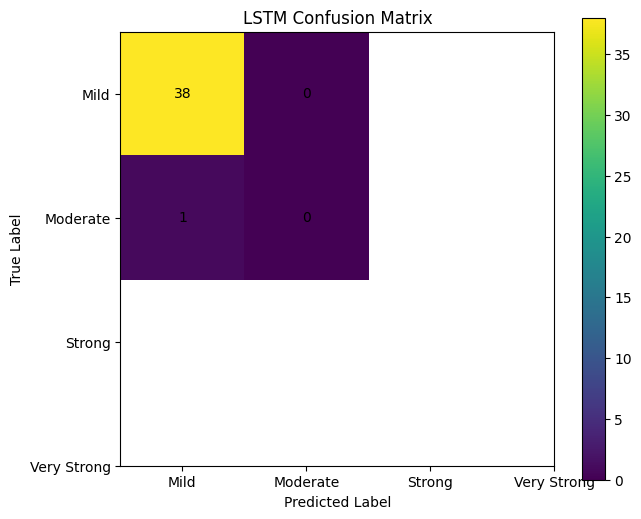

In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))

plt.imshow(cm)

plt.title("LSTM Confusion Matrix")

plt.colorbar()

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

labels = [
    'Mild',
    'Moderate',
    'Strong',
    'Very Strong'
]

plt.xticks(range(4), labels)
plt.yticks(range(4), labels)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.show()

Plot Training Performance

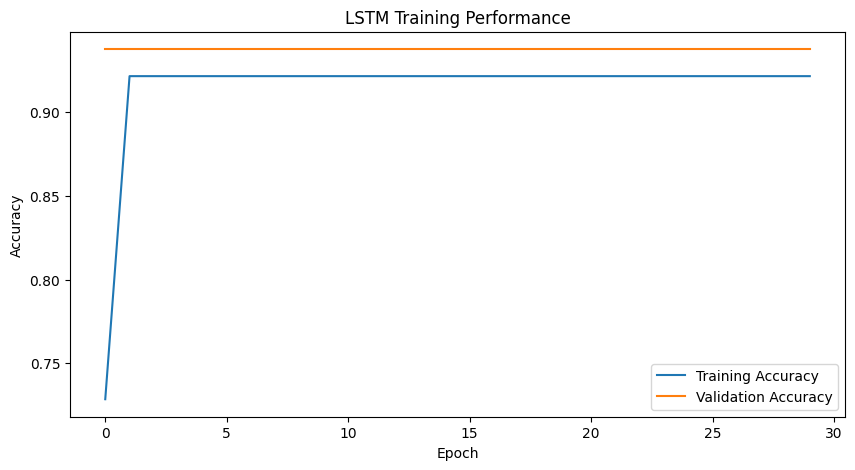

In [14]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.title('LSTM Training Performance')

plt.legend()

plt.show()

PREDICTION FUNCTION

In [15]:
def predict_earthquake(sequence_data):

    sequence_data = np.array(sequence_data)

    sequence_data = scaler.transform(sequence_data)

    sequence_data = np.expand_dims(
        sequence_data,
        axis=0
    )

    prediction = model.predict(sequence_data)

    predicted_class = np.argmax(prediction)

    probability = np.max(prediction) * 100

    classes = [
        "Mild Earthquake",
        "Moderate Earthquake",
        "Strong Earthquake",
        "Very Strong Earthquake"
    ]

    return {
        "Prediction": classes[predicted_class],
        "Confidence": f"{probability:.2f}%"
    }

Test Prediction

In [16]:
sample_sequence = [

    [9.10, 40.02, 10.0, 4.2],
    [9.20, 40.10, 10.0, 4.3],
    [9.25, 40.05, 10.0, 4.4],
    [9.30, 40.08, 10.0, 4.5],
    [9.36, 40.02, 10.0, 4.3]
]

result = predict_earthquake(sample_sequence)

print("\nPREDICTION RESULT")
print("-----------------")
print(result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step

PREDICTION RESULT
-----------------
{'Prediction': 'Moderate Earthquake', 'Confidence': '93.34%'}


Save Model

In [17]:
model.save("earthquake_lstm.keras")

print("LSTM Model Saved Successfully")

LSTM Model Saved Successfully


Convert to TensorFlow Lite

In [19]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# IMPORTANT FIX FOR LSTM
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]

converter._experimental_lower_tensor_list_ops = False

tflite_model = converter.convert()

with open("earthquake_lstm.tflite", "wb") as f:
    f.write(tflite_model)

print("TFLite Model Saved Successfully")

Saved artifact at '/tmp/tmpc_81_dsy'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 5, 4), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  138265801596112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138265801598608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138265801596496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138268264307920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138265801599184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138265801599376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138265801598800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138265801598032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138265801598992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138265801599568: TensorSpec(shape=(), dtype=tf.resource, name=None)
TFLite Model Saved Succ

Download Models

In [20]:
files.download("earthquake_lstm.keras")

files.download("earthquake_lstm.tflite")

files.download("lstm_scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>